In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import roc_auc_score, roc_curve
import random

Intertidal taxa: (514, 4)
Nearshore taxa: (514, 4)
Intertidal links: (6775, 2)
Nearshore links: (6775, 2)

Sanak Intertidal Network:
Nodes: 239 | Edges: 1806
Density: 0.0317 | Avg Clustering: 0.2145

Sanak Nearshore Network:
Nodes: 516 | Edges: 6775
Density: 0.0255 | Avg Clustering: 0.2401


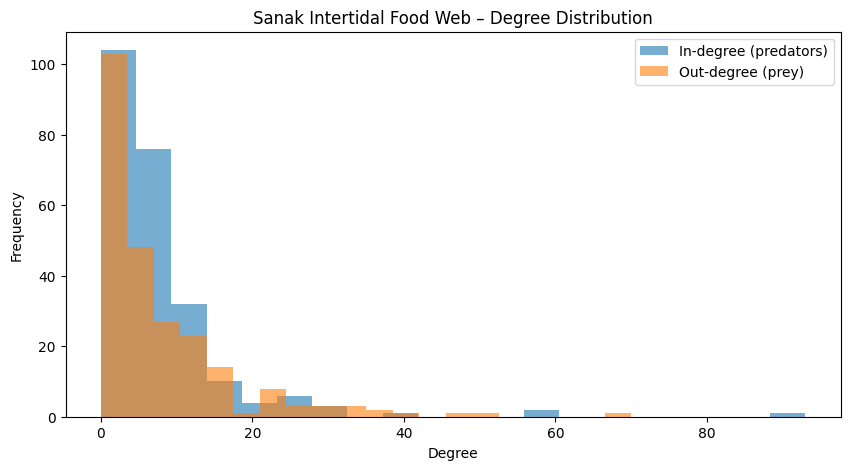

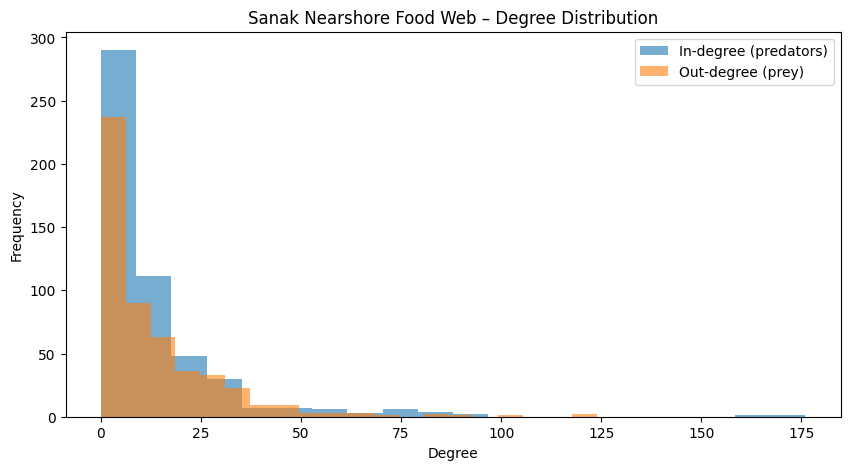

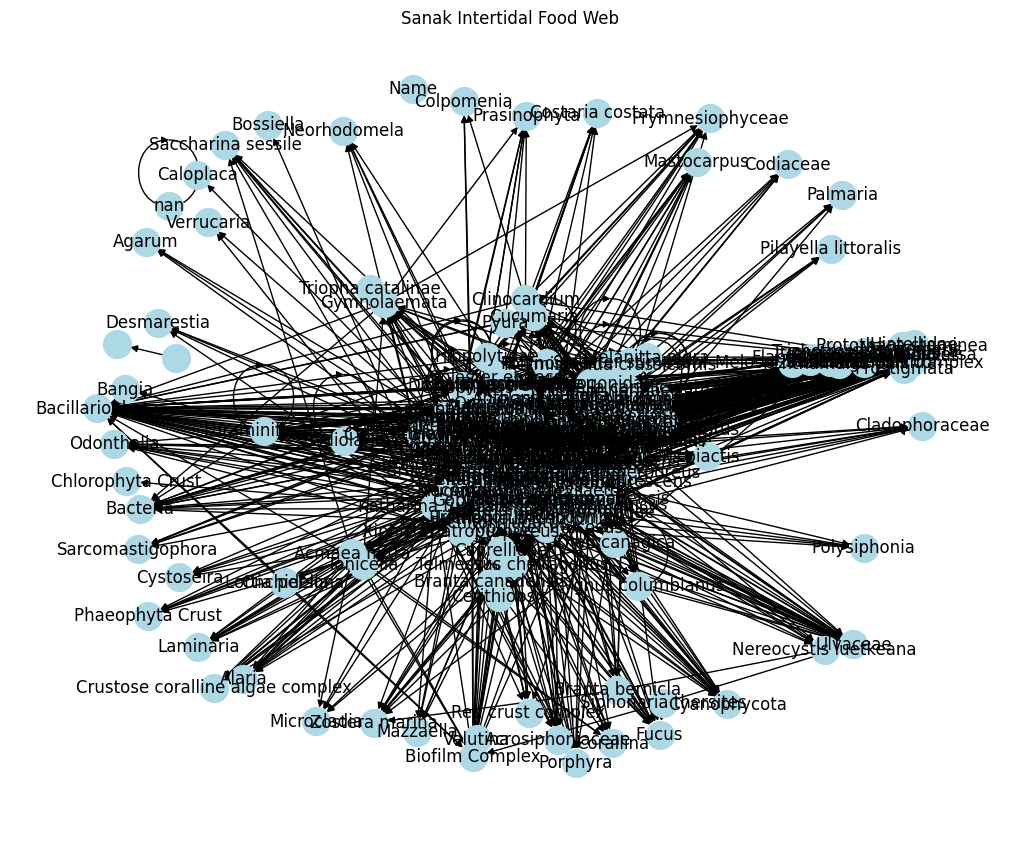

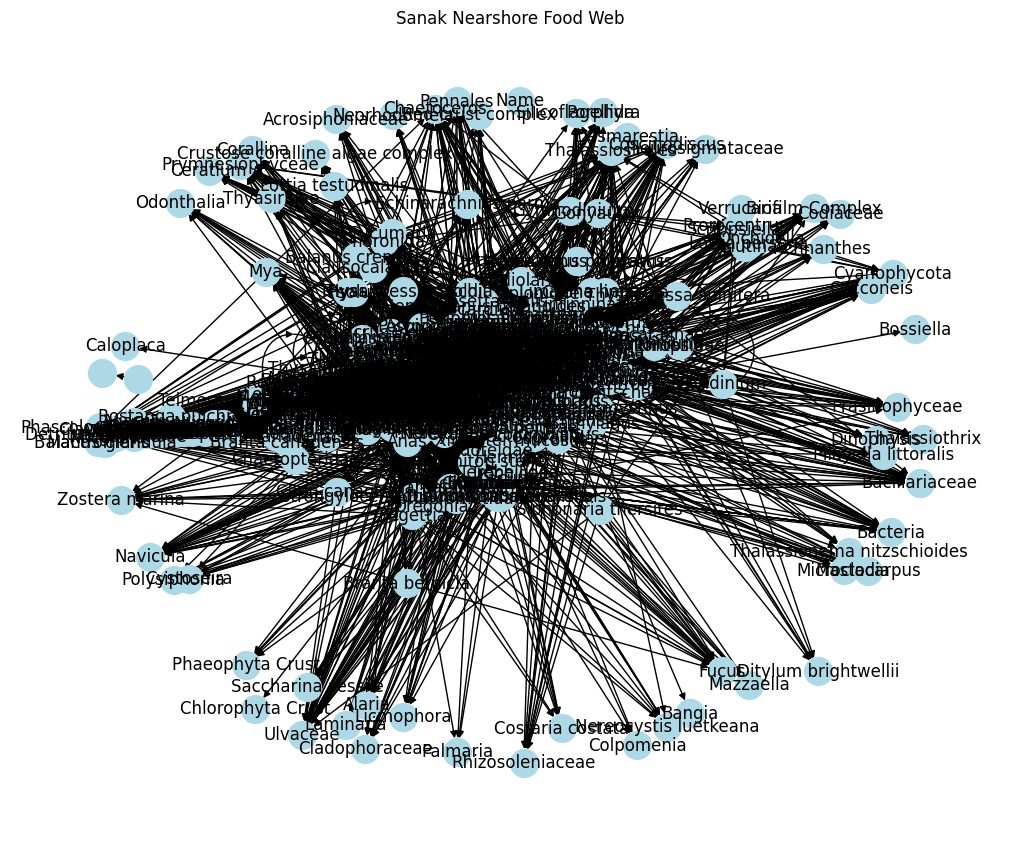

Removed: set()
Removed 1 isolated nodes from Intertidal graph.
Removed 1 isolated nodes from Nearshore graph.


In [2]:



file_path = "Foodweb/data.xls"
xls = pd.ExcelFile(file_path)

taxa_df = pd.read_excel(xls, xls.sheet_names[0])
links_df = pd.read_excel(xls, xls.sheet_names[1])


taxa_intertidal = taxa_df.iloc[:, 0:4]
taxa_intertidal.columns = ['ID', 'TSN', 'Name', 'Phylum']

links_intertidal = links_df.iloc[:, 0:2]
links_intertidal.columns = ['Consumer', 'Resource']

taxa_nearshore = taxa_df.iloc[:, 5:9]
taxa_nearshore.columns = ['ID', 'TSN', 'Name', 'Phylum']

links_nearshore = links_df.iloc[:, 3:5]
links_nearshore.columns = ['Consumer', 'Resource']

print("Intertidal taxa:", taxa_intertidal.shape)
print("Nearshore taxa:", taxa_nearshore.shape)
print("Intertidal links:", links_intertidal.shape)
print("Nearshore links:", links_nearshore.shape)

G_intertidal = nx.DiGraph()
G_nearshore = nx.DiGraph()

for _, row in taxa_intertidal.iterrows():
    G_intertidal.add_node(row['ID'], name=row['Name'], phylum=row['Phylum'])

for _, row in taxa_nearshore.iterrows():
    G_nearshore.add_node(row['ID'], name=row['Name'], phylum=row['Phylum'])

for _, row in links_intertidal.iterrows():
    G_intertidal.add_edge(row['Consumer'], row['Resource'])

for _, row in links_nearshore.iterrows():
    G_nearshore.add_edge(row['Consumer'], row['Resource'])

def network_stats(G, name):
    density = nx.density(G)
    clustering = nx.average_clustering(G.to_undirected())
    print(f"\n{name} Network:")
    print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
    print(f"Density: {density:.4f} | Avg Clustering: {clustering:.4f}")

network_stats(G_intertidal, "Sanak Intertidal")
network_stats(G_nearshore, "Sanak Nearshore")

def plot_degree_distribution(G, title):
    in_deg = [deg for _, deg in G.in_degree()]
    out_deg = [deg for _, deg in G.out_degree()]

    plt.figure(figsize=(10,5))
    plt.hist(in_deg, bins=20, alpha=0.6, label='In-degree (predators)')
    plt.hist(out_deg, bins=20, alpha=0.6, label='Out-degree (prey)')
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title(f"{title} – Degree Distribution")
    plt.legend()
    plt.show()

plot_degree_distribution(G_intertidal, "Sanak Intertidal Food Web")
plot_degree_distribution(G_nearshore, "Sanak Nearshore Food Web")

def plot_network(G, title):
    plt.figure(figsize=(10,8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, node_size=400, node_color='lightblue',
            arrowsize=10, with_labels=True,
            labels=nx.get_node_attributes(G, 'name'))
    plt.title(title)
    plt.show()

plot_network(G_intertidal, "Sanak Intertidal Food Web")
plot_network(G_nearshore, "Sanak Nearshore Food Web")

bad_nodes = {"Consumer", "Resource"}
G_intertidal.remove_nodes_from(bad_nodes)
G_nearshore.remove_nodes_from(bad_nodes)

print("Removed:", bad_nodes & set(G_intertidal.nodes()))
isolated_nodes = list(nx.isolates(G_intertidal))
G_intertidal.remove_nodes_from(isolated_nodes)

isolated_nodes_nearshore = list(nx.isolates(G_nearshore))
G_nearshore.remove_nodes_from(isolated_nodes_nearshore)

print(f"Removed {len(isolated_nodes)} isolated nodes from Intertidal graph.")
print(f"Removed {len(isolated_nodes_nearshore)} isolated nodes from Nearshore graph.")
def fix_missing_phyla(taxa_df):
    taxa_df.loc[taxa_df['Name'].str.strip().eq("Detritus complex"), 'Phylum'] = "Detritus complex"
    taxa_df.loc[taxa_df['Name'].str.strip().eq("Biofilm Complex"), 'Phylum'] = "Biofilm Complex"
    return taxa_df

taxa_intertidal = fix_missing_phyla(taxa_intertidal)
taxa_nearshore = fix_missing_phyla(taxa_nearshore)



In [3]:
intertidal_phyla_counts = taxa_intertidal['Phylum'].value_counts()
nearshore_phyla_counts = taxa_nearshore['Phylum'].value_counts()

print("=== Sanak Intertidal Food Web ===")
print(intertidal_phyla_counts)
print(f"\nTotal distinct phyla: {len(intertidal_phyla_counts)}")

print("\n=== Sanak Nearshore Food Web ===")
print(nearshore_phyla_counts)
print(f"\nTotal distinct phyla: {len(nearshore_phyla_counts)}")


=== Sanak Intertidal Food Web ===
Phylum
Chordata             83
Mollusca             45
Arthropoda           25
Echinodermata        14
Rhodophyta           13
Phaeophyta           12
Annelida              7
Cnidaria              5
Chlorophyta           5
Nemertea              3
Porifera              3
Protozoa              2
Ascomycota            2
Cyanophycota          1
Prasinophyta          1
Pyrrophycophyta       1
Detritus complex      1
Phylum                1
Magnoliophyta         1
Ciliophora            1
Sarcomastigophora     1
Bacillariophyta       1
Haptophyta            1
Bacteria              1
Brachiopoda           1
Ectoprocta            1
Phoronida             1
Sipuncula             1
Chrysophyta           1
Biofilm Complex       1
Name: count, dtype: int64

Total distinct phyla: 30

=== Sanak Nearshore Food Web ===
Phylum
Chordata             233
Mollusca              65
Arthropoda            62
Annelida              26
Echinodermata         23
Bacillariophyta      

Intertidal: 29 phyla, 163 inter-phyla links
Nearshore: 34 phyla, 194 inter-phyla links


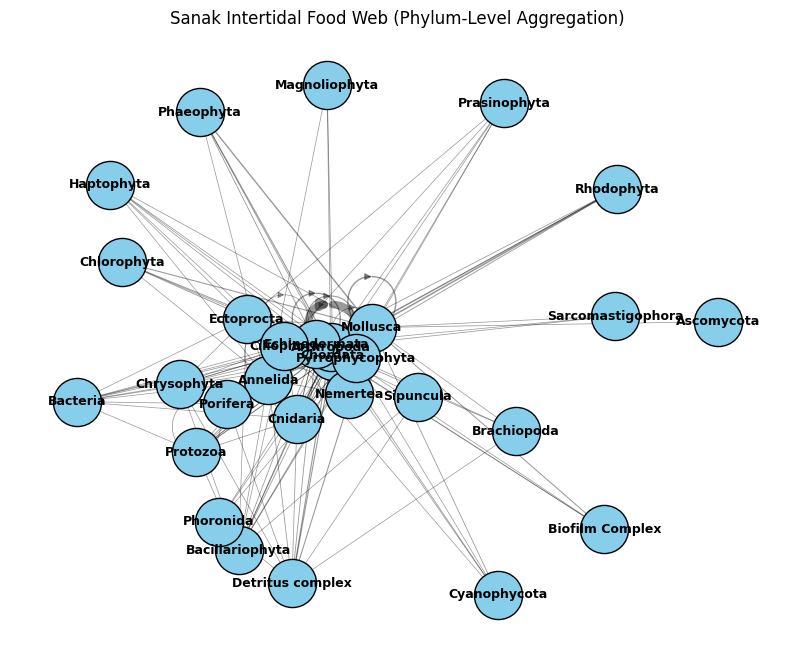

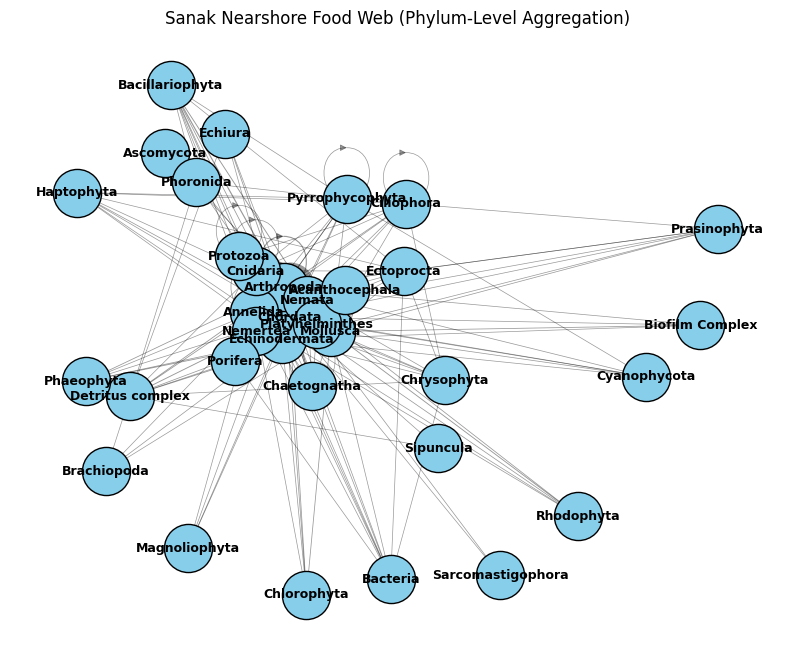

In [4]:


def aggregate_by_phylum(G, taxa_df):
    """Collapse nodes by phylum."""
    id_to_phylum = taxa_df.set_index('ID')['Phylum'].to_dict()

    edges = []
    for u, v in G.edges():
        phyl_u = id_to_phylum.get(u)
        phyl_v = id_to_phylum.get(v)
        if phyl_u and phyl_v:
            edges.append((phyl_u, phyl_v))

    df_edges = pd.DataFrame(edges, columns=['PredatorPhylum', 'PreyPhylum'])
    counts = df_edges.value_counts().reset_index(name='Weight')

    G_phy = nx.DiGraph()
    for _, row in counts.iterrows():
        G_phy.add_edge(row['PredatorPhylum'], row['PreyPhylum'], weight=row['Weight'])

    return G_phy

def plot_phylum_network(G_phy, title):
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_phy, seed=42, k=0.8)

    weights = [G_phy[u][v]['weight'] for u, v in G_phy.edges()]
    widths = [0.5 + w / max(weights) * 5 for w in weights]

    nx.draw_networkx_edges(G_phy, pos, width=widths, alpha=0.4, arrowsize=10)
    nx.draw_networkx_nodes(G_phy, pos, node_size=1200, node_color='skyblue', edgecolors='black')
    nx.draw_networkx_labels(G_phy, pos, font_size=9, font_weight='bold')

    plt.title(title)
    plt.axis('off')
    plt.show()

G_intertidal_phy = aggregate_by_phylum(G_intertidal, taxa_intertidal)
G_nearshore_phy = aggregate_by_phylum(G_nearshore, taxa_nearshore)

print(f"Intertidal: {G_intertidal_phy.number_of_nodes()} phyla, {G_intertidal_phy.number_of_edges()} inter-phyla links")
print(f"Nearshore: {G_nearshore_phy.number_of_nodes()} phyla, {G_nearshore_phy.number_of_edges()} inter-phyla links")

plot_phylum_network(G_intertidal_phy, "Sanak Intertidal Food Web (Phylum-Level Aggregation)")
plot_phylum_network(G_nearshore_phy, "Sanak Nearshore Food Web (Phylum-Level Aggregation)")


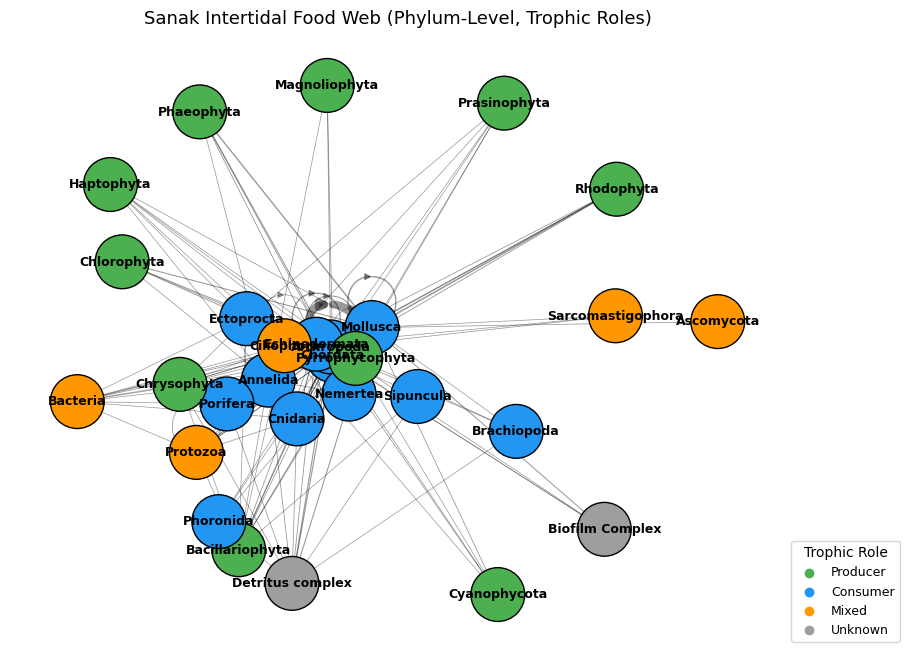

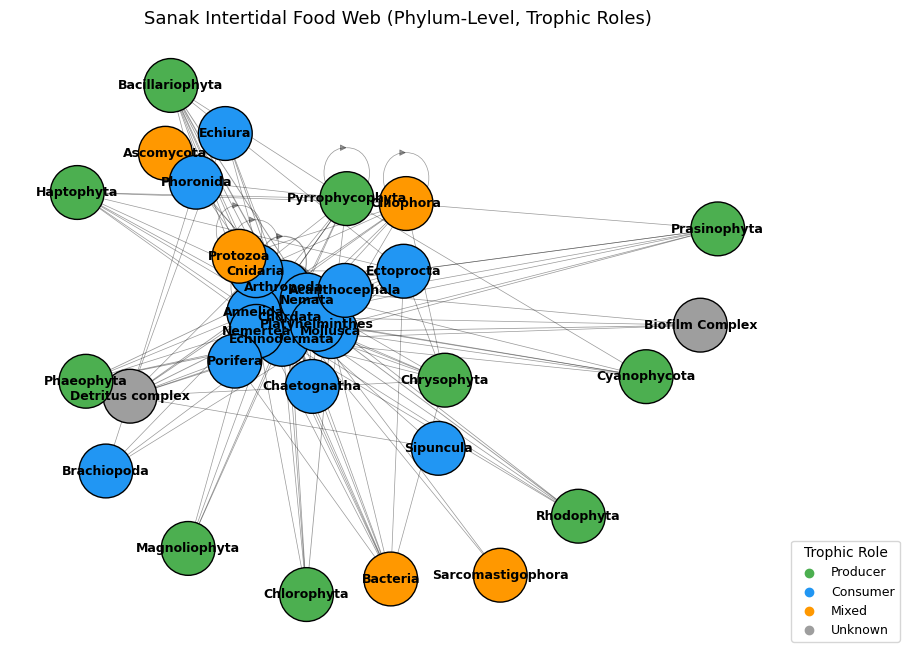

In [5]:
trophic_role_map = {
    # --- Producers (autotrophs, photosynthetic taxa) ---
    "Chlorophyta": "producer",
    "Rhodophyta": "producer",
    "Phaeophyta": "producer",
    "Bacillariophyta": "producer",
    "Cyanophycota": "producer",
    "Prasinophyta": "producer",
    "Magnoliophyta": "producer",
    "Haptophyta": "producer",
    "Chrysophyta": "producer",
    "Pyrrophycophyta": "producer",  # Dinoflagellates, mostly photosynthetic

    # --- Consumers (heterotrophic animals) ---
    "Chordata": "consumer",
    "Mollusca": "consumer",
    "Arthropoda": "consumer",
    "Echinodermata": "consumer",
    "Annelida": "consumer",
    "Cnidaria": "consumer",
    "Porifera": "consumer",
    "Nemertea": "consumer",
    "Brachiopoda": "consumer",
    "Ectoprocta": "consumer",
    "Phoronida": "consumer",
    "Sipuncula": "consumer",
    "Platyhelminthes": "consumer",
    "Acanthocephala": "consumer",
    "Nemata": "consumer",
    "Chaetognatha": "consumer",
    "Echiura": "consumer",

    # --- Mixed / decomposers / unclear ---
    "Ascomycota": "mixed",       # Fungi (decomposers)
    "Bacteria": "mixed",         # Decomposers / mixed heterotrophs
    "Protozoa": "mixed",         # Micro-consumers
    "Ciliophora": "mixed",       # Microbial consumers
    "Sarcomastigophora": "mixed",# Mixed protists

    # --- Unknown / ambiguous placeholders ---
    "Phylum": "unknown",         # Placeholder in dataset
}

def classify_trophic_role(phylum):
    return trophic_role_map.get(phylum, "unknown")


def plot_phylum_network_colored(G_phy, title):
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}

    color_map = {
        "producer": "#4CAF50",   # green
        "consumer": "#2196F3",   # blue
        "mixed": "#FF9800",      # orange
        "unknown": "#9E9E9E"     # gray
    }
    node_colors = [color_map[trophic_role[n]] for n in G_phy.nodes()]

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_phy, seed=42, k=0.8)

    weights = [G_phy[u][v]['weight'] for u, v in G_phy.edges()]
    widths = [0.5 + w / max(weights) * 5 for w in weights]

    nx.draw_networkx_edges(G_phy, pos, width=widths, alpha=0.4, arrowsize=10)
    nx.draw_networkx_nodes(G_phy, pos, node_size=1500, node_color=node_colors, edgecolors='black')
    nx.draw_networkx_labels(G_phy, pos, font_size=9, font_weight='bold')

    plt.title(title, fontsize=13)
    plt.axis('off')

    for role, color in color_map.items():
        plt.scatter([], [], color=color, label=role.title())
    plt.legend(title="Trophic Role", loc="lower left", bbox_to_anchor=(1, 0), fontsize=9)

    plt.show()

plot_phylum_network_colored(G_intertidal_phy, "Sanak Intertidal Food Web (Phylum-Level, Trophic Roles)")
plot_phylum_network_colored(G_nearshore_phy, "Sanak Intertidal Food Web (Phylum-Level, Trophic Roles)")


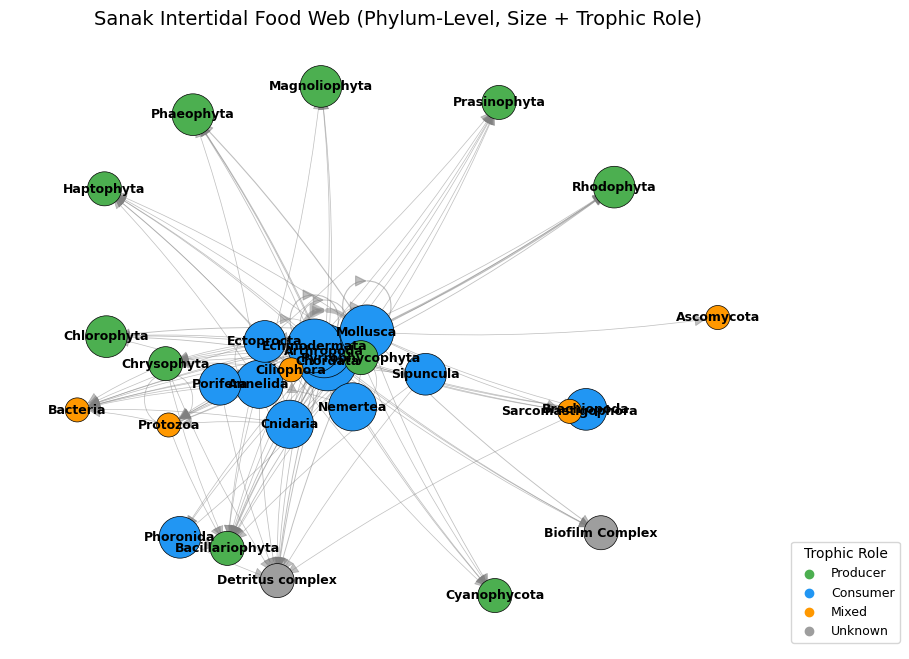

In [6]:


phylum_size_map = {
    "Chordata": 6, "Mollusca": 5, "Arthropoda": 5, "Echinodermata": 5,
    "Annelida": 4, "Cnidaria": 4, "Nemertea": 4, "Brachiopoda": 3,
    "Phoronida": 3, "Sipuncula": 3, "Porifera": 3, "Ectoprocta": 3,
    "Platyhelminthes": 3, "Acanthocephala": 3, "Nemata": 3,
    "Chaetognatha": 3, "Echiura": 3,

    "Chlorophyta": 3, "Rhodophyta": 3, "Phaeophyta": 3,
    "Bacillariophyta": 2, "Prasinophyta": 2, "Haptophyta": 2,
    "Cyanophycota": 2, "Magnoliophyta": 3, "Pyrrophycophyta": 2,
    "Chrysophyta": 2,

    "Ascomycota": 1, "Bacteria": 1, "Protozoa": 1,
    "Ciliophora": 1, "Sarcomastigophora": 1, "Phylum": 1,
}

def get_node_size(phylum):
    """Convert phylum size category to node area (scaled for plotting)."""
    return 300 * phylum_size_map.get(phylum, 2)

def plot_phylum_network_colored_size(G_phy, title):
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}

    color_map = {
        "producer": "#4CAF50",   # green
        "consumer": "#2196F3",   # blue
        "mixed": "#FF9800",      # orange
        "unknown": "#9E9E9E"     # gray
    }

    node_colors = [color_map[trophic_role[n]] for n in G_phy.nodes()]
    node_sizes = [get_node_size(n) for n in G_phy.nodes()]

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G_phy, seed=42, k=0.9)

    weights = [G_phy[u][v]['weight'] for u, v in G_phy.edges()]
    max_w = max(weights) if weights else 1
    widths = [0.5 + (w / max_w) * 3 for w in weights]

    nx.draw_networkx_edges(
        G_phy, pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        edge_color="gray",
        width=widths,
        alpha=0.5,
        connectionstyle="arc3,rad=0.05"
    )

    nx.draw_networkx_nodes(G_phy, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_labels(G_phy, pos, font_size=9, font_weight='bold')

    plt.title(title, fontsize=14)
    plt.axis('off')

    for role, color in color_map.items():
        plt.scatter([], [], color=color, label=role.title())
    plt.legend(title="Trophic Role", loc="lower left", bbox_to_anchor=(1, 0), fontsize=9)

    plt.show()

plot_phylum_network_colored_size(G_intertidal_phy, "Sanak Intertidal Food Web (Phylum-Level, Size + Trophic Role)")


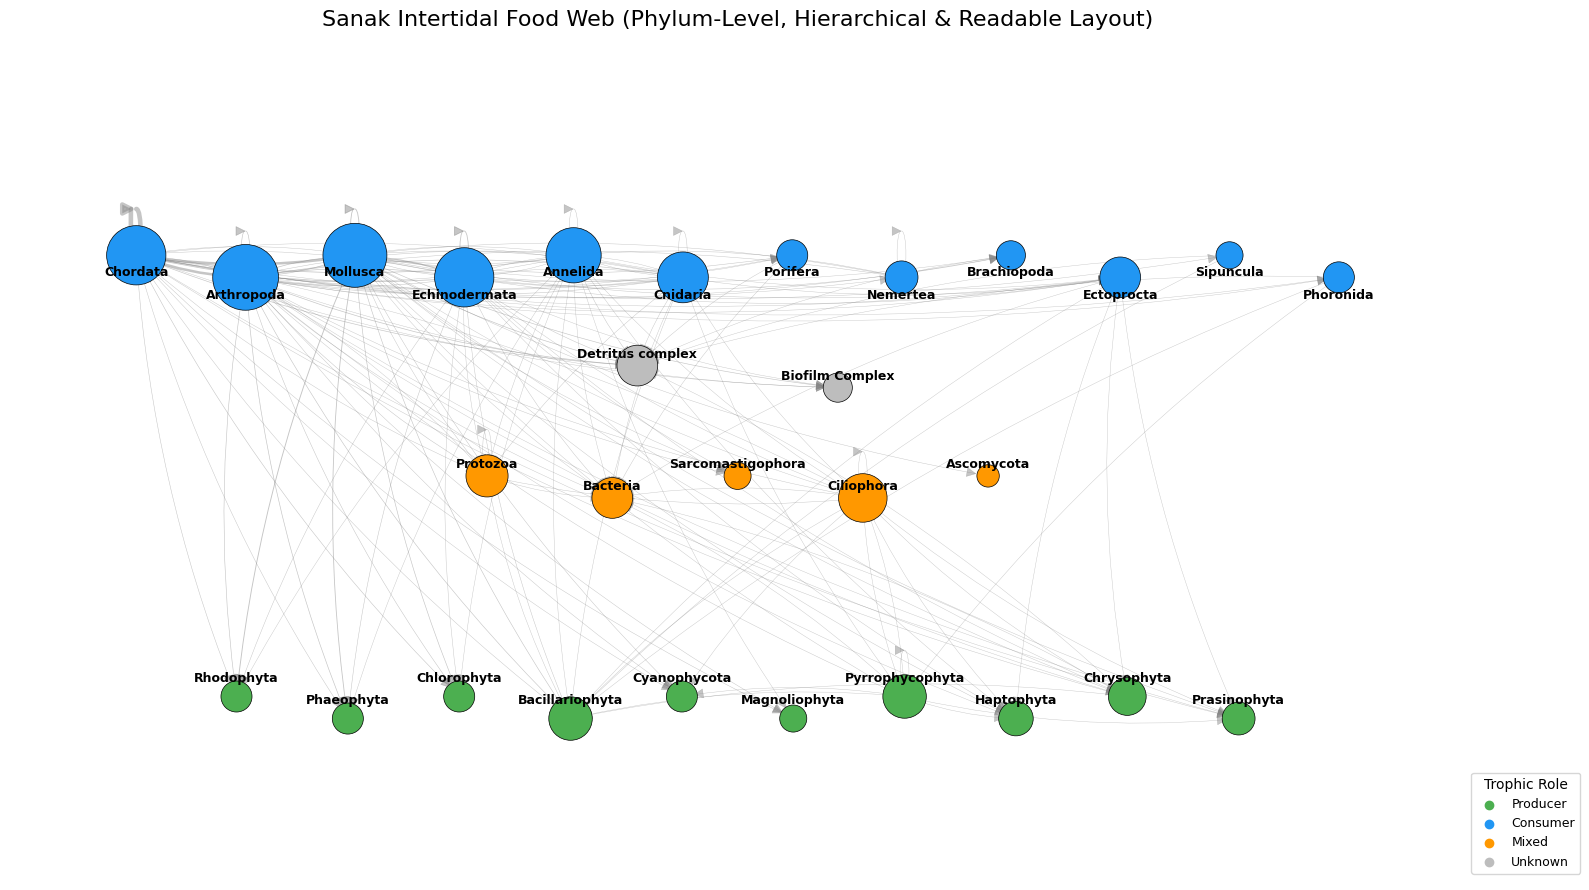

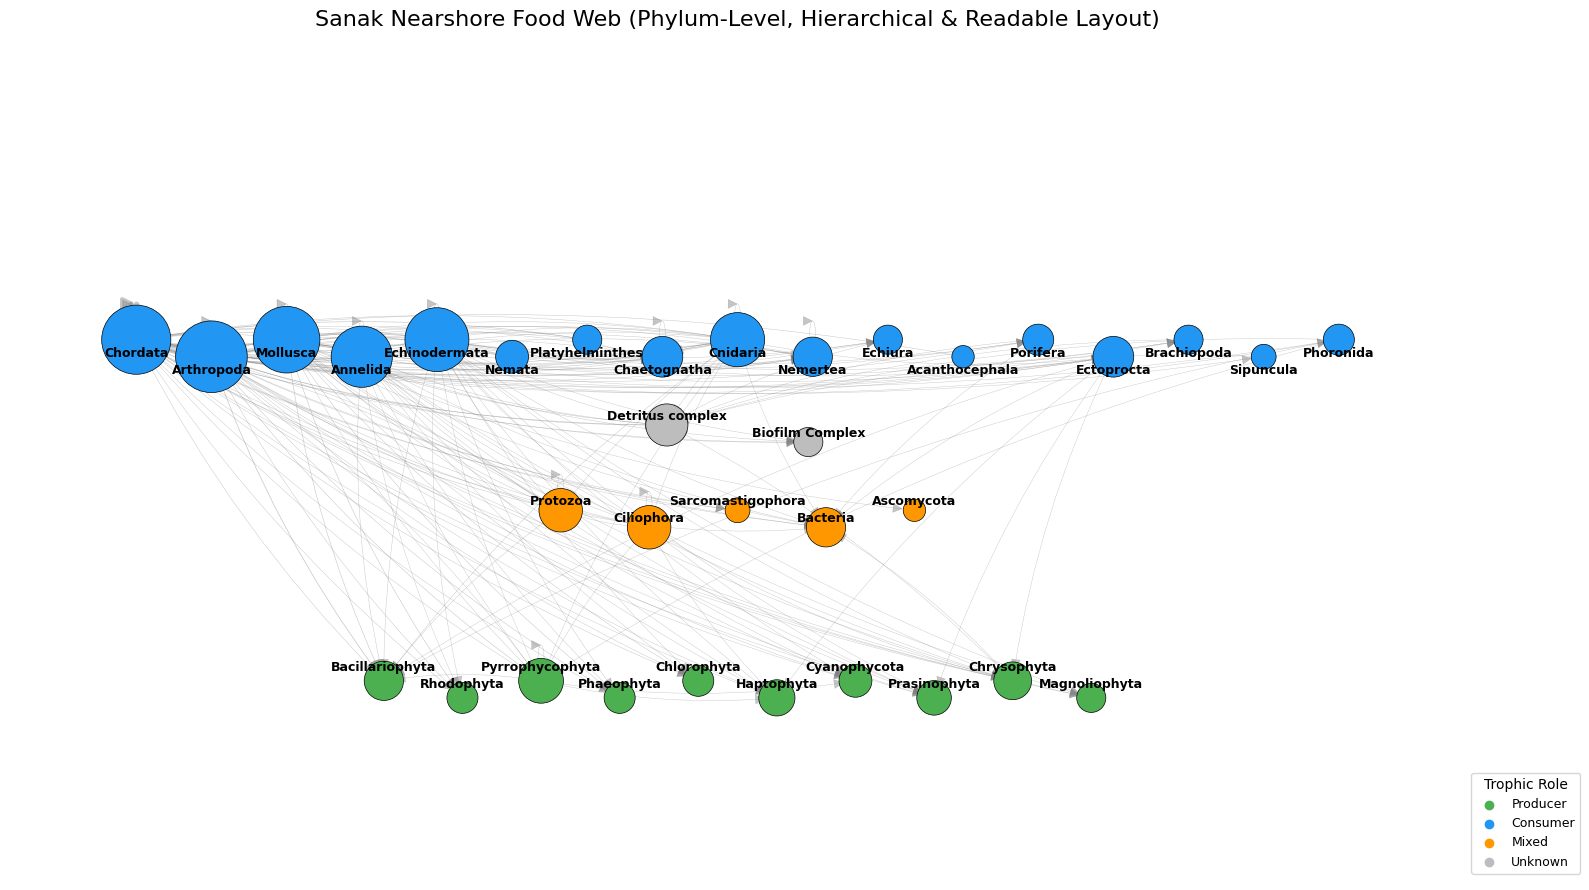

In [7]:


def hierarchical_foodweb_layout_spread(G_phy, spacing=1.2):
    """Layout with evenly spaced nodes per trophic role and label staggering."""
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}
    y_level = {"producer": -2, "mixed": -1, "consumer": 0, "unknown": -0.5}
    grouped = {"producer": [], "mixed": [], "consumer": [], "unknown": []}

    for node, role in trophic_role.items():
        grouped[role].append(node)

    pos = {}
    for role, nodes in grouped.items():
        y = y_level[role]
        n = len(nodes)
        if n == 0:
            continue
        xs = np.linspace(-n * spacing / 2, n * spacing / 2, n)
        for i, node in enumerate(nodes):
            jitter = 0.05 * (-1) ** i  
            pos[node] = (xs[i], y + jitter)
    return pos


def plot_phylum_network_clean(G_phy, title):
    """Draw a hierarchical phylum-level food web showing all nodes, including unique unknowns."""
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}

    color_map = {
        "producer": "#4CAF50",   # green
        "consumer": "#2196F3",   # blue
        "mixed": "#FF9800",      # orange
        "unknown": "#BDBDBD"     # light gray for individual unknowns
    }

    def get_node_size(node):
        deg = G_phy.degree(node)
        return 200 + 60 * deg  

    node_colors = [color_map.get(trophic_role.get(n, "unknown"), "#BDBDBD") for n in G_phy.nodes()]
    node_sizes = [get_node_size(n) for n in G_phy.nodes()]

    plt.figure(figsize=(16, 9))
    pos = hierarchical_foodweb_layout_spread(G_phy, spacing=1.8)

    if G_phy.number_of_edges() > 0:
        weights = [G_phy[u][v].get('weight', 1) for u, v in G_phy.edges()]
        max_w = max(weights)
        widths = [0.3 + (w / max_w) * 3 for w in weights]
        nx.draw_networkx_edges(
            G_phy, pos,
            arrows=True, arrowstyle="-|>", arrowsize=16,
            edge_color="gray", width=widths, alpha=0.45,
            connectionstyle="arc3,rad=0.08"
        )

    nx.draw_networkx_nodes(
        G_phy, pos, node_size=node_sizes,
        node_color=node_colors, edgecolors='black', linewidths=0.5
    )

    label_offsets = {
        node: (0, 0.08) if trophic_role.get(node) == "producer" else
              (0, -0.08) if trophic_role.get(node) == "consumer" else
              (0, 0.05)
        for node in G_phy.nodes()
    }

    for node, (x, y) in pos.items():
        dx, dy = label_offsets[node]
        plt.text(
            x + dx, y + dy, node,
            fontsize=9, ha='center', va='center', fontweight='bold'
        )

    plt.title(title, fontsize=16, pad=20)
    plt.axis("off")

    for role, color in color_map.items():
        plt.scatter([], [], color=color, label=role.title())
    plt.legend(title="Trophic Role", loc="lower left", bbox_to_anchor=(1, 0), fontsize=9)

    plt.tight_layout()
    plt.show()



plot_phylum_network_clean(G_intertidal_phy, "Sanak Intertidal Food Web (Phylum-Level, Hierarchical & Readable Layout)")
plot_phylum_network_clean(G_nearshore_phy, "Sanak Nearshore Food Web (Phylum-Level, Hierarchical & Readable Layout)")



In [8]:

def merge_foodwebs(G1, G2):
    """
    Merge two directed food web graphs.
    - Keeps all nodes and edges from both.
    - If the same edge appears in both, sums their weights.
    """
    G_merged = nx.DiGraph()

    G_merged.add_nodes_from(G1.nodes(data=True))
    G_merged.add_nodes_from(G2.nodes(data=True))

    def add_edges_from_graph(G):
        for u, v, data in G.edges(data=True):
            w = data.get("weight", 1)
            if G_merged.has_edge(u, v):
                G_merged[u][v]["weight"] += w
            else:
                G_merged.add_edge(u, v, weight=w)

    add_edges_from_graph(G1)
    add_edges_from_graph(G2)

    print(f"  Nodes: {G_merged.number_of_nodes()}")
    print(f"  Edges: {G_merged.number_of_edges()}")
    return G_merged

G_merged = merge_foodwebs(G_intertidal, G_nearshore)


  Nodes: 514
  Edges: 8514


In [9]:


def merge_phylum_foodwebs(G_intertidal_phy, G_nearshore_phy):
    """
    Merge two phylum-level food webs into one.
    - Keeps all nodes from both graphs
    - Combines edges
    - Tags each edge with its source: 'intertidal', 'nearshore', or 'both'
    - Sums weights where both share the same edge
    """
    G_merged_phy = nx.DiGraph()
    
    G_merged_phy.add_nodes_from(G_intertidal_phy.nodes(data=True))
    G_merged_phy.add_nodes_from(G_nearshore_phy.nodes(data=True))

    for u, v, data in G_intertidal_phy.edges(data=True):
        w = data.get("weight", 1)
        G_merged_phy.add_edge(u, v, weight=w, source="intertidal")

    for u, v, data in G_nearshore_phy.edges(data=True):
        w = data.get("weight", 1)
        if G_merged_phy.has_edge(u, v):
            G_merged_phy[u][v]["weight"] += w
            G_merged_phy[u][v]["source"] = "both"
        else:
            G_merged_phy.add_edge(u, v, weight=w, source="nearshore")

    print(f"  Nodes: {G_merged_phy.number_of_nodes()}")
    print(f"  Edges: {G_merged_phy.number_of_edges()}")
    
    return G_merged_phy


G_merged_phy = merge_phylum_foodwebs(G_intertidal_phy, G_nearshore_phy)


  Nodes: 34
  Edges: 205


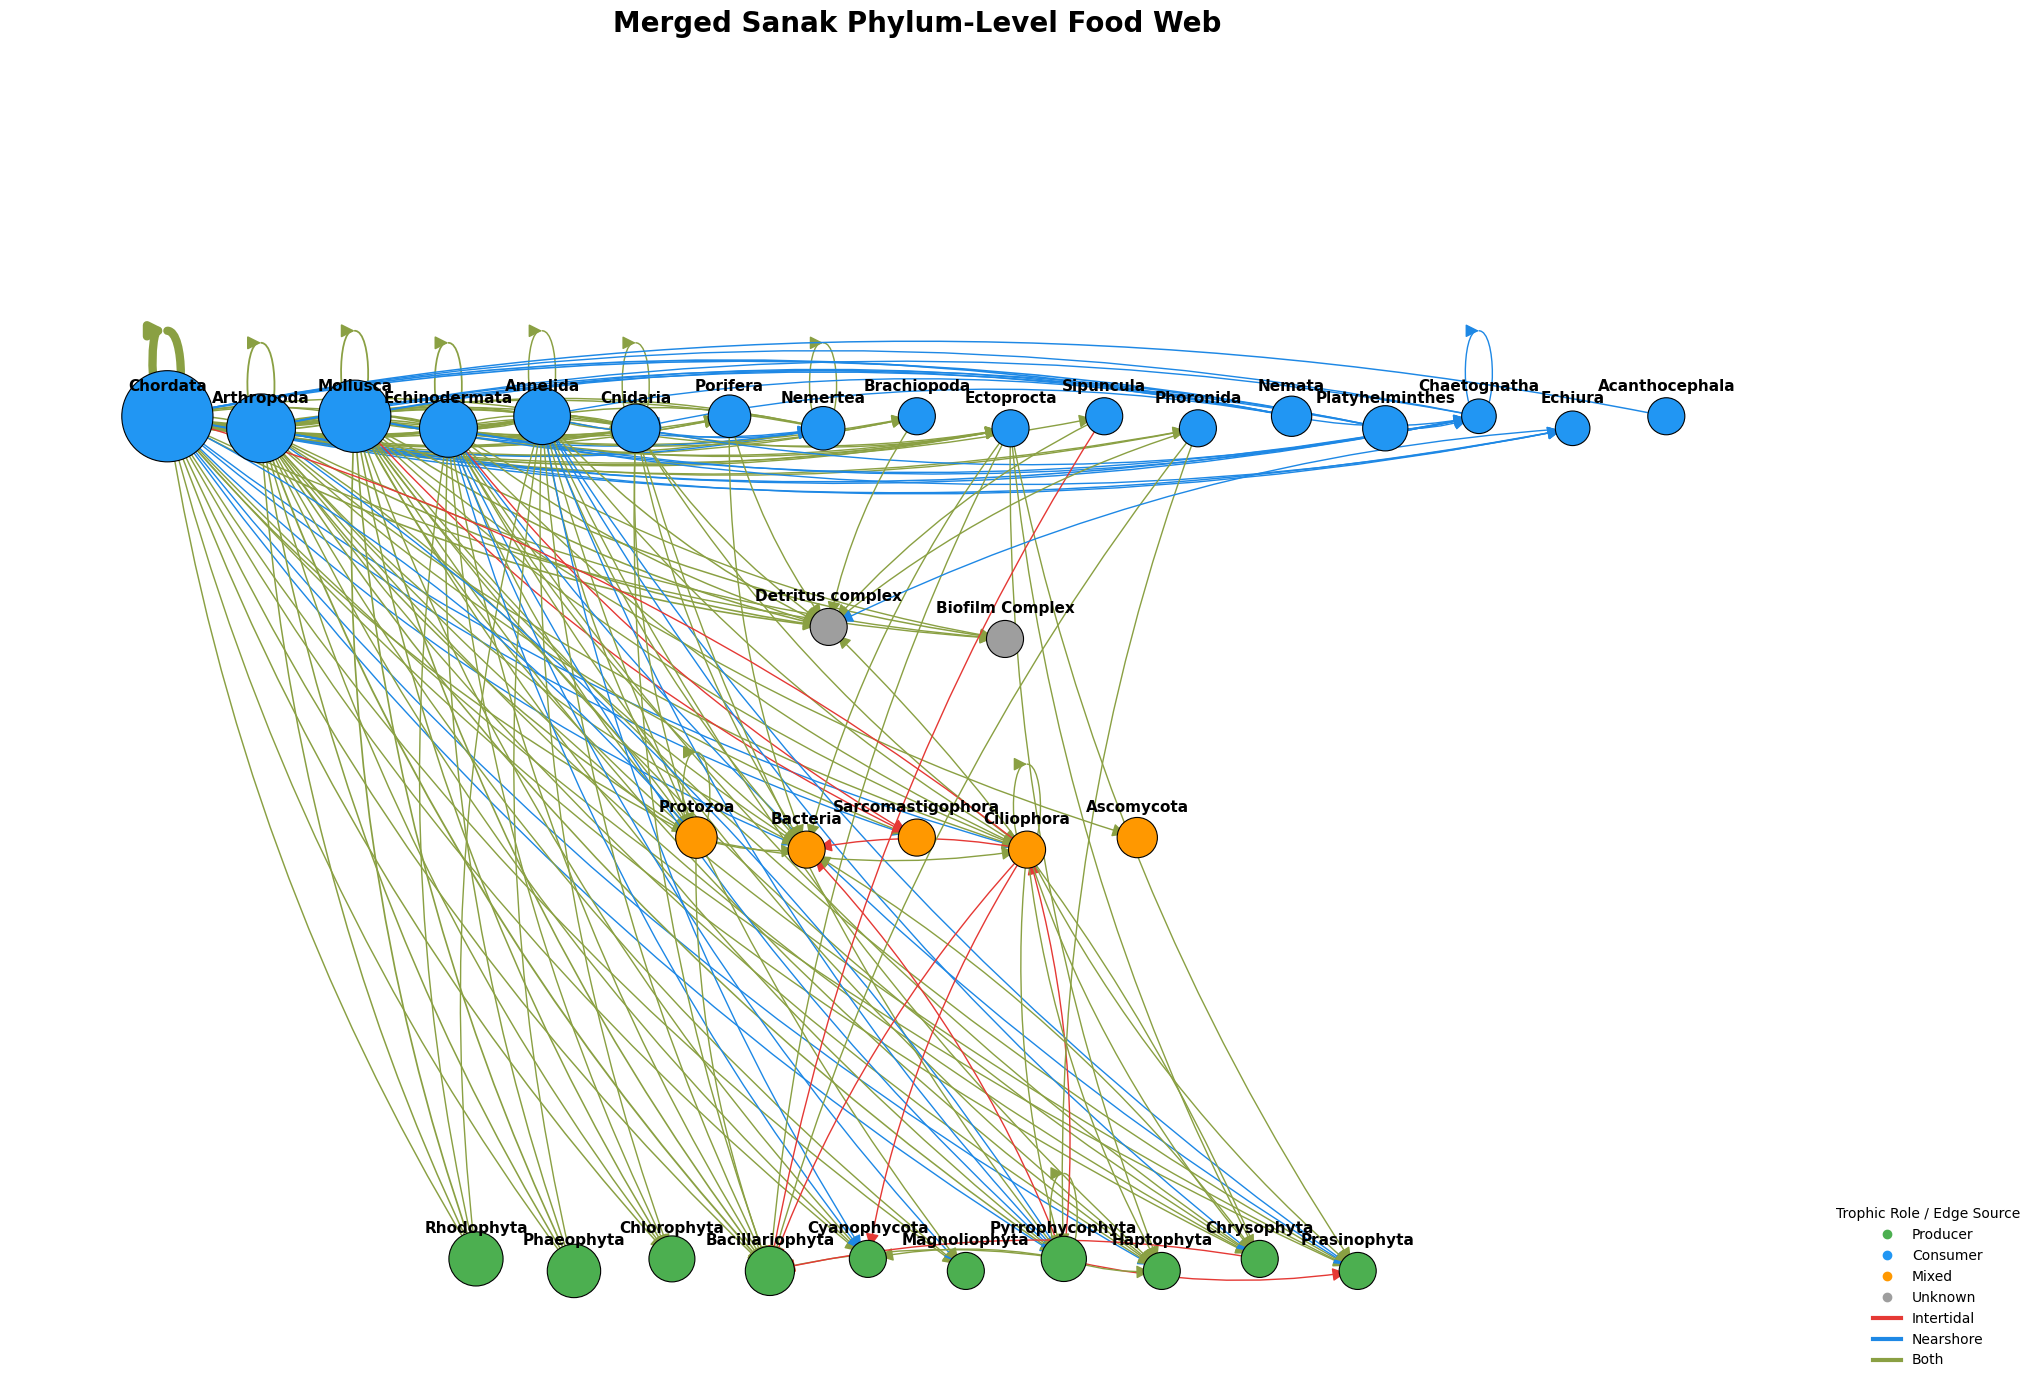

In [10]:


def hierarchical_foodweb_layout_expanded(G_phy, spacing_x=3.0, spacing_y=2.5):
    """Improved hierarchical layout that spreads nodes vertically and horizontally."""
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}
    grouped = {"producer": [], "mixed": [], "consumer": [], "unknown": []}
    for node, role in trophic_role.items():
        grouped[role].append(node)

    y_level = {"producer": -spacing_y, "mixed": 0, "unknown": spacing_y * 0.5, "consumer": spacing_y}

    pos = {}
    for role, nodes in grouped.items():
        n = len(nodes)
        if n == 0:
            continue
        xs = np.linspace(-n * spacing_x / 4, n * spacing_x / 4, n)
        y = y_level[role]
        for i, node in enumerate(nodes):
            pos[node] = (xs[i], y + 0.05 * (-1) ** i)
    return pos


def plot_phylum_network_scaled_full(G_phy, taxa_df, title):
    """Draw full-screen phylum-level web with scaled nodes and full layout use."""
    plt.figure(figsize=(22, 14))
    pos = hierarchical_foodweb_layout_expanded(G_phy, spacing_x=3.5, spacing_y=3.5)

    phylum_sizes = taxa_df["Phylum"].value_counts().to_dict()
    trophic_role = {n: classify_trophic_role(n) for n in G_phy.nodes()}

    color_map = {
        "producer": "#4CAF50",
        "consumer": "#2196F3",
        "mixed": "#FF9800",
        "unknown": "#9E9E9E"
    }

    def get_node_size(node):
        base = 400
        size = phylum_sizes.get(node, 1)
        return base + np.sqrt(size) * 220

    node_sizes = [get_node_size(n) for n in G_phy.nodes()]
    node_colors = [color_map[trophic_role.get(n, "unknown")] for n in G_phy.nodes()]

    source_colors = {
        "intertidal": "#E53935",  # red
        "nearshore": "#1E88E5",   # blue
        "both": "#8AA043"         # green
    }

    edge_weights = nx.get_edge_attributes(G_phy, 'weight')
    max_w = max(edge_weights.values()) if edge_weights else 1
    edge_widths = [1 + 5 * (G_phy[u][v].get("weight", 1) / max_w) for u, v in G_phy.edges()]
    edge_colors = [source_colors.get(G_phy[u][v].get("source", "both"), "#43A047") for u, v in G_phy.edges()]

    nx.draw_networkx_edges(
        G_phy, pos,
        arrows=True, arrowstyle="-|>", arrowsize=20,
        edge_color=edge_colors, width=edge_widths,
        alpha=1.0, connectionstyle="arc3,rad=0.1"
    )

    nx.draw_networkx_nodes(
        G_phy, pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors='black', linewidths=0.8
    )

    for n, (x, y) in pos.items():
        plt.text(x, y + 0.25, n, fontsize=11, ha='center', va='center', fontweight='bold')

    edge_patches = [plt.Line2D([0], [0], color=c, lw=3, label=label.title())
                    for label, c in source_colors.items()]
    node_patches = [plt.Line2D([0], [0], color=c, marker='o', linestyle='', label=label.title())
                    for label, c in color_map.items()]

    plt.legend(handles=node_patches + edge_patches,
               title="Trophic Role / Edge Source",
               loc="lower left", bbox_to_anchor=(1, 0),
               fontsize=10, frameon=False)

    plt.title(title, fontsize=20, fontweight="bold", pad=30)
    plt.axis("off")
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()



plot_phylum_network_scaled_full(
    G_merged_phy,
    pd.concat([taxa_intertidal, taxa_nearshore], ignore_index=True),
    "Merged Sanak Phylum-Level Food Web"
)




In [11]:
nodes_intertidal = set(G_intertidal_phy.nodes())
nodes_nearshore  = set(G_nearshore_phy.nodes())

shared_nodes = nodes_intertidal & nodes_nearshore
node_jaccard = len(shared_nodes) / len(nodes_intertidal | nodes_nearshore) * 100

print(f"Shared phyla: {len(shared_nodes)} / {len(nodes_intertidal | nodes_nearshore)} ({node_jaccard:.1f}%)")

edges_intertidal = set(G_intertidal_phy.edges())
edges_nearshore  = set(G_nearshore_phy.edges())

shared_edges = edges_intertidal & edges_nearshore
edge_jaccard = len(shared_edges) / len(edges_intertidal | edges_nearshore) * 100

print(f"Shared phylum-level interactions: {len(shared_edges)} / {len(edges_intertidal | edges_nearshore)} ({edge_jaccard:.1f}%)")

def weighted_jaccard(G1, G2):
    w1 = {(u,v): d['weight'] for u,v,d in G1.edges(data=True)}
    w2 = {(u,v): d['weight'] for u,v,d in G2.edges(data=True)}
    all_edges = set(w1) | set(w2)
    num = sum(min(w1.get(e,0), w2.get(e,0)) for e in all_edges)
    den = sum(max(w1.get(e,0), w2.get(e,0)) for e in all_edges)
    return num / den if den > 0 else 0

weighted_similarity = weighted_jaccard(G_intertidal_phy, G_nearshore_phy) * 100
print(f"Weighted structural similarity: {weighted_similarity:.1f}%")


Shared phyla: 29 / 34 (85.3%)
Shared phylum-level interactions: 152 / 205 (74.1%)
Weighted structural similarity: 26.4%


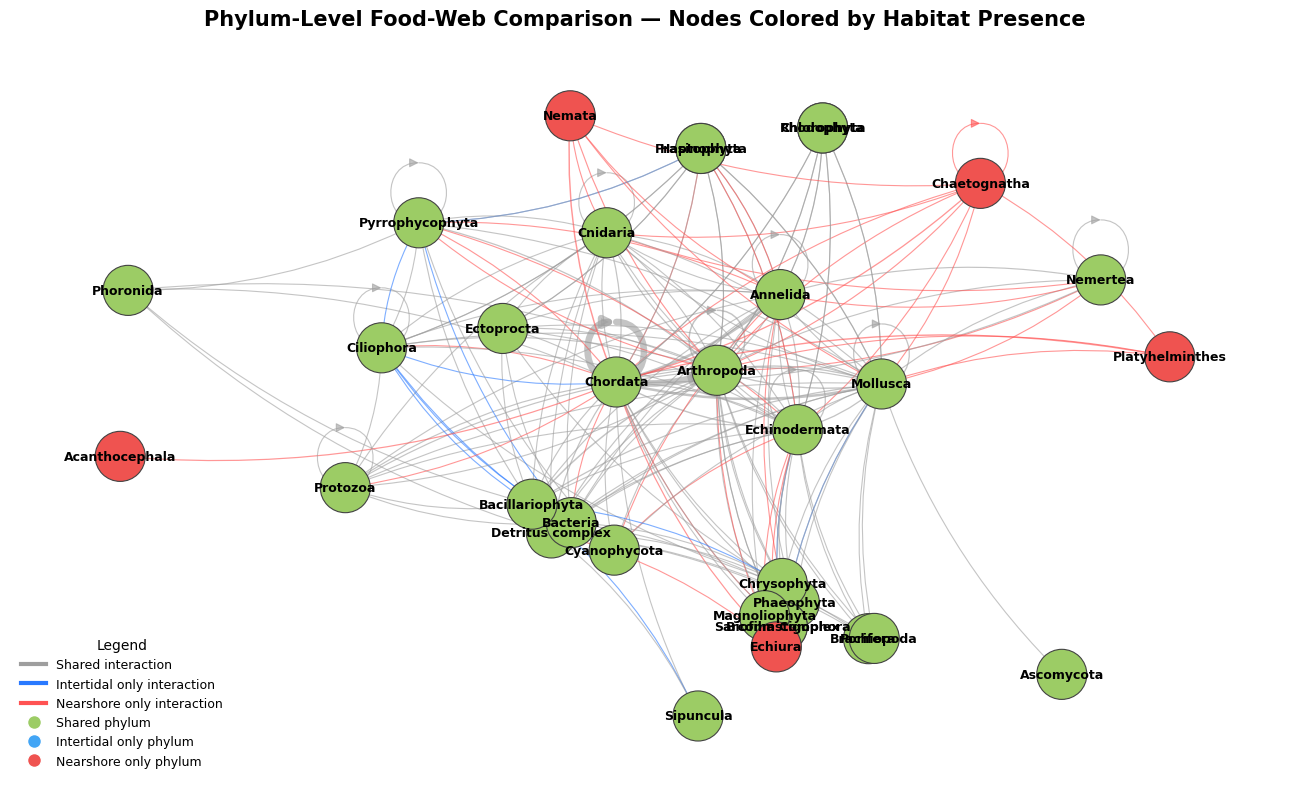

In [12]:


def plot_foodweb_overlap_with_node_colours(G1, G2, title):
    """
    Compare two phylum-level food webs (G1=Intertidal, G2=Nearshore)
    Colors:
      - Edges: shared/unique
      - Nodes: shared/intertidal-only/nearshore-only
      - Edge width: difference in interaction strength
    """
    w1 = {(u, v): d['weight'] for u, v, d in G1.edges(data=True)}
    w2 = {(u, v): d['weight'] for u, v, d in G2.edges(data=True)}
    all_edges = set(w1) | set(w2)

    Gd = nx.DiGraph()
    for e in all_edges:
        diff = abs(w1.get(e, 0) - w2.get(e, 0))
        if e in w1 and e in w2:
            color = "#9E9E9E"  # shared
        elif e in w1:
            color = "#2979FF"  # intertidal only
        else:
            color = "#FF5252"  # nearshore only
        Gd.add_edge(*e, color=color, diff=diff)

    nodes_1 = set(G1.nodes())
    nodes_2 = set(G2.nodes())

    node_colors = {}
    for n in set(nodes_1 | nodes_2):
        if n in nodes_1 and n in nodes_2:
            node_colors[n] = "#9CCC65"  # greenish = shared
        elif n in nodes_1:
            node_colors[n] = "#42A5F5"  # blue = intertidal only
        else:
            node_colors[n] = "#EF5350"  # red = nearshore only
        Gd.add_node(n)

    edge_colors = [Gd[u][v]["color"] for u, v in Gd.edges()]
    edge_diffs = [Gd[u][v]["diff"] for u, v in Gd.edges()]
    max_diff = max(edge_diffs) if edge_diffs else 1
    widths = [0.8 + 4 * (d / max_diff) for d in edge_diffs]

    node_color_list = [node_colors[n] for n in Gd.nodes()]
    node_size_list = [1300] * len(Gd.nodes())

    pos = nx.kamada_kawai_layout(Gd, weight=None)
    for k, (x, y) in pos.items():
        pos[k] = (x * 1.3, y * 1.1)

    plt.figure(figsize=(13, 8))
    nx.draw_networkx_edges(
        Gd, pos,
        edge_color=edge_colors,
        width=widths,
        alpha=0.6,
        connectionstyle="arc3,rad=0.12",
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
    )
    nx.draw_networkx_nodes(
        Gd, pos,
        node_size=node_size_list,
        node_color=node_color_list,
        edgecolors="#424242",
        linewidths=0.8
    )
    nx.draw_networkx_labels(Gd, pos, font_size=9, font_weight="bold")

    edge_legend = [
        plt.Line2D([], [], color="#9E9E9E", lw=3, label="Shared interaction"),
        plt.Line2D([], [], color="#2979FF", lw=3, label="Intertidal only interaction"),
        plt.Line2D([], [], color="#FF5252", lw=3, label="Nearshore only interaction")
    ]
    node_legend = [
        plt.Line2D([], [], marker="o", color="w", label="Shared phylum",
                   markerfacecolor="#9CCC65", markersize=10),
        plt.Line2D([], [], marker="o", color="w", label="Intertidal only phylum",
                   markerfacecolor="#42A5F5", markersize=10),
        plt.Line2D([], [], marker="o", color="w", label="Nearshore only phylum",
                   markerfacecolor="#EF5350", markersize=10)
    ]

    plt.legend(
        handles=edge_legend + node_legend,
        title="Legend",
        loc="lower left", bbox_to_anchor=(0, 0),
        fontsize=9, frameon=False
    )

    plt.title(title, fontsize=15, fontweight="semibold", pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


plot_foodweb_overlap_with_node_colours(
    G_intertidal_phy, G_nearshore_phy,
    "Phylum-Level Food-Web Comparison — Nodes Colored by Habitat Presence"
)


In [13]:

def plot_species_network_colored(G, taxa_df, title):
    """
    Plot the original species-level food web with nodes colored by trophic role.
    """
    plt.figure(figsize=(14, 10))

    taxa_df["Phylum"] = taxa_df["Phylum"].fillna("Unknown").astype(str)
    id_to_phylum = taxa_df.set_index("ID")["Phylum"].to_dict()
    id_to_name = taxa_df.set_index("ID")["Name"].to_dict()

    roles = {n: classify_trophic_role(id_to_phylum.get(n, "Unknown")) for n in G.nodes()}

    color_map = {
        "producer": "#4CAF50",   # green
        "consumer": "#2196F3",   # blue
        "mixed": "#FF9800",      # orange
        "unknown": "#9E9E9E"     # gray
    }
    node_colors = [color_map.get(roles[n], "#9E9E9E") for n in G.nodes()]

    labels = {n: id_to_name.get(n, str(n)) for n in G.nodes()}

    pos = nx.spring_layout(G, seed=42, k=0.3)

    nx.draw_networkx_edges(G, pos, alpha=0.2, arrowsize=6, edge_color="gray")
    nx.draw_networkx_nodes(
        G, pos,
        node_size=60,
        node_color=node_colors,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.9
    )

    degree = dict(G.degree())
    high_deg_nodes = [n for n, d in degree.items() if d > (sum(degree.values()) / len(degree))]
    label_subset = {n: labels[n] for n in high_deg_nodes}
    nx.draw_networkx_labels(G, pos, labels=label_subset, font_size=7, font_weight="bold")

    plt.title(title, fontsize=15, fontweight="bold")
    for role, color in color_map.items():
        plt.scatter([], [], color=color, s=80, label=role.title())
    plt.legend(title="Trophic Role", loc="lower left", fontsize=9, frameon=False)

    plt.axis("off")
    plt.tight_layout()
    plt.show()


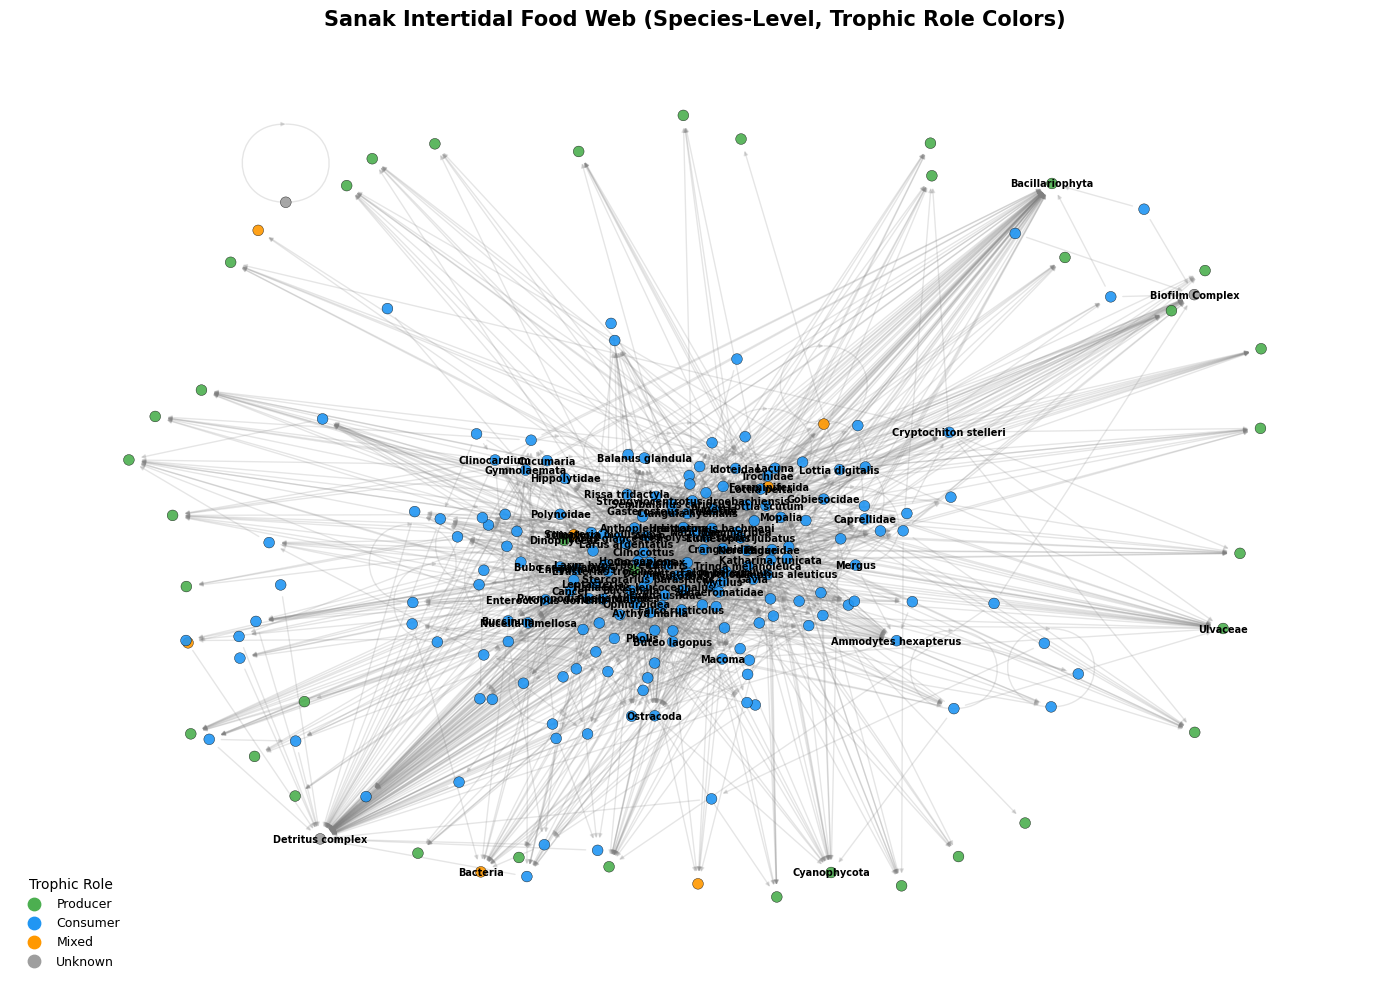

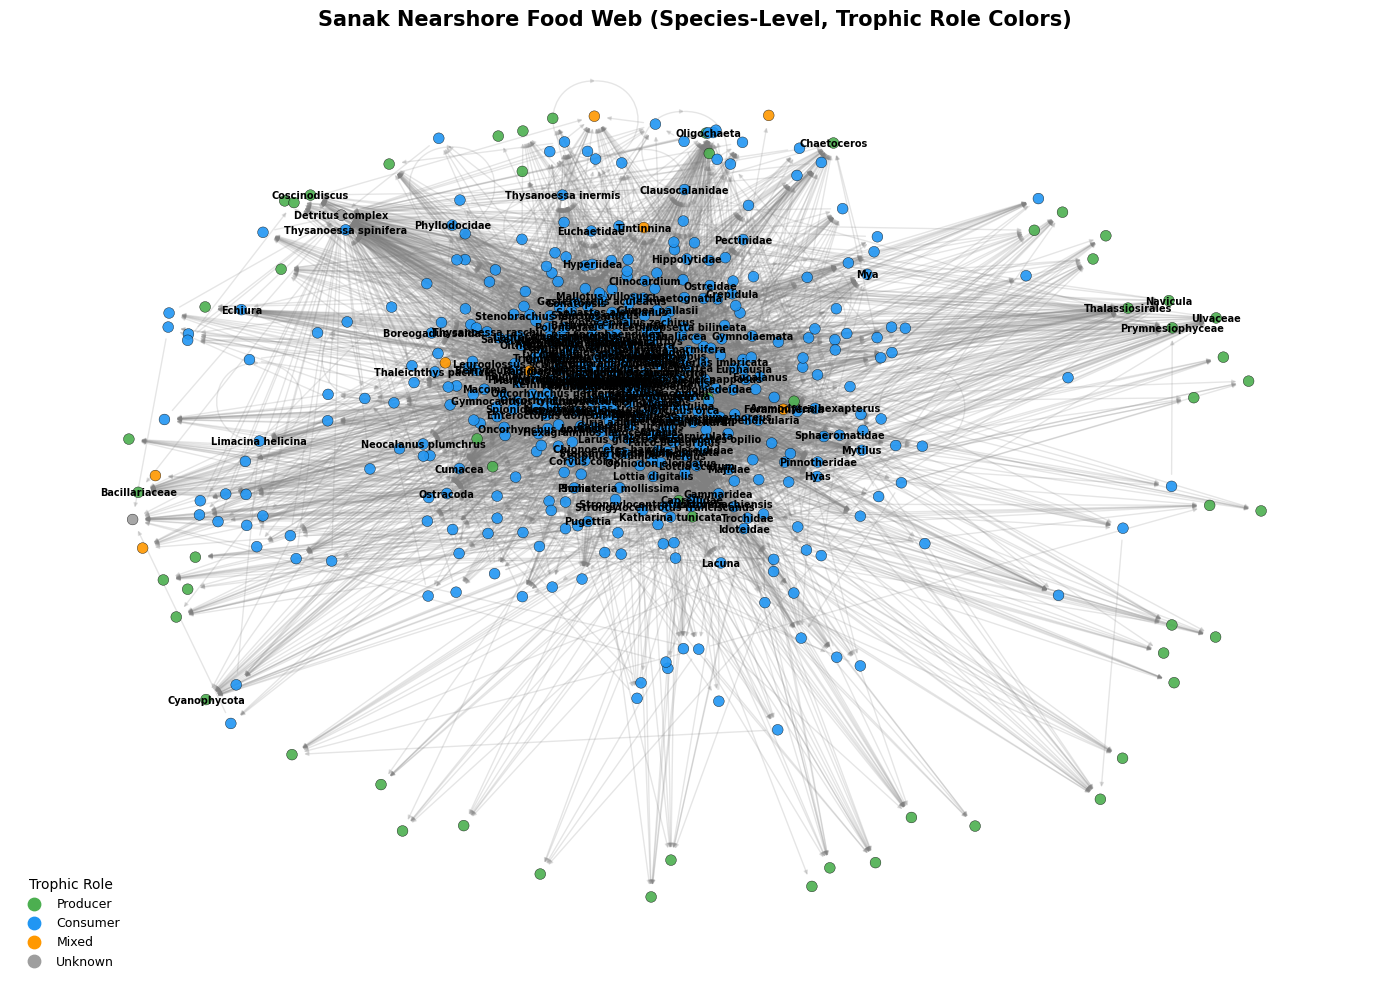

In [14]:
plot_species_network_colored(G_intertidal, taxa_intertidal, "Sanak Intertidal Food Web (Species-Level, Trophic Role Colors)")
plot_species_network_colored(G_nearshore, taxa_nearshore, "Sanak Nearshore Food Web (Species-Level, Trophic Role Colors)")


In [15]:

def directed_jaccard_coefficient(G, u, v):
    """Compute a symmetric Jaccard coefficient using both in- and out-neighbors."""
    neigh_u = set(G.successors(u)) | set(G.predecessors(u))
    neigh_v = set(G.successors(v)) | set(G.predecessors(v))
    if not neigh_u or not neigh_v:
        return 0.0
    return len(neigh_u & neigh_v) / len(neigh_u | neigh_v)
import random

import random

def getPredictionsLeaveOneOutDirectedJaccard(G, n_neg=20):
    """
    Leave-one-out link prediction using directed Jaccard.
    For each removed edge, compute similarity for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())
    all_possible_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_jaccard_coefficient(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = [(a, b) for (a, b) in all_possible_pairs if not Gprobed.has_edge(a, b)]

        if not non_edges:
            continue  

        sampled_non_edges = random.sample(non_edges, min(n_neg, len(non_edges)))
        for (a, b) in sampled_non_edges:
            p_neg = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels


def computeTFPositiveRates(probs, labels):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(labels, probs)
    return tpr.tolist(), fpr.tolist()


def aucLeaveOneOutDirectedJaccard(G):
    probs, labels = getPredictionsLeaveOneOutDirectedJaccard(G)
    auc = roc_auc_score(labels, probs)
    return auc




In [16]:
def directed_preferential_attachment(G, u, v):
    """Directed preferential attachment = outdegree(u) * indegree(v)."""
    return G.out_degree(u) * G.in_degree(v)
import random

def getPredictionsLeaveOneOutDirectedPA(G, n_neg=20):
    """
    Leave-one-out link prediction using directed preferential attachment.
    For each removed edge, compute the score for that edge (positive)
    and n_neg random non-edges (negatives).
    """
    probs, labels = [], []
    nodes = list(G.nodes())

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        p_pos = directed_preferential_attachment(Gprobed, u, v)
        probs.append(p_pos)
        labels.append(1)

        non_edges = set()
        while len(non_edges) < n_neg:
            a, b = random.sample(nodes, 2)
            if not Gprobed.has_edge(a, b):
                non_edges.add((a, b))

        for (a, b) in non_edges:
            p_neg = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p_neg)
            labels.append(0)

    return probs, labels



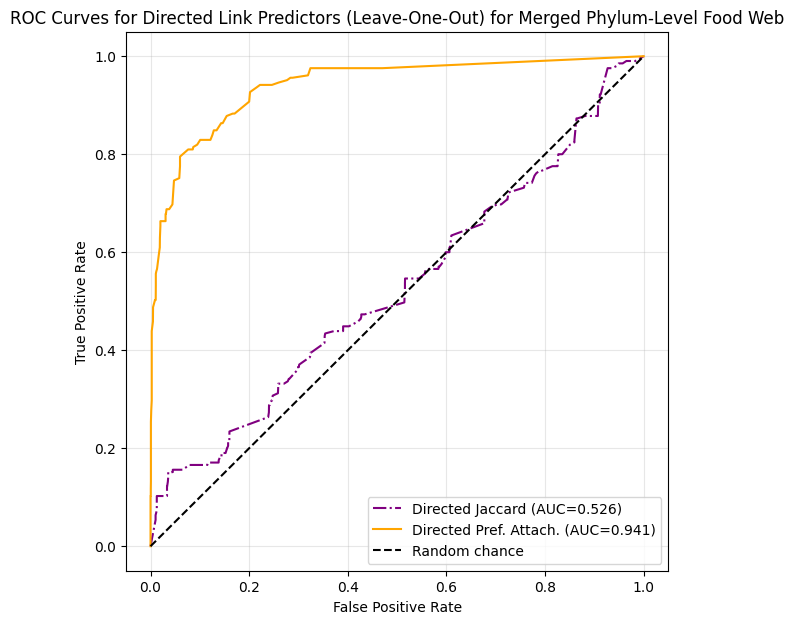

AUC (Directed Jaccard): 0.5255
AUC (Directed Preferential Attachment): 0.9406


In [17]:

probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_merged_phy)
probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_merged_phy)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out) for Merged Phylum-Level Food Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa:.4f}")

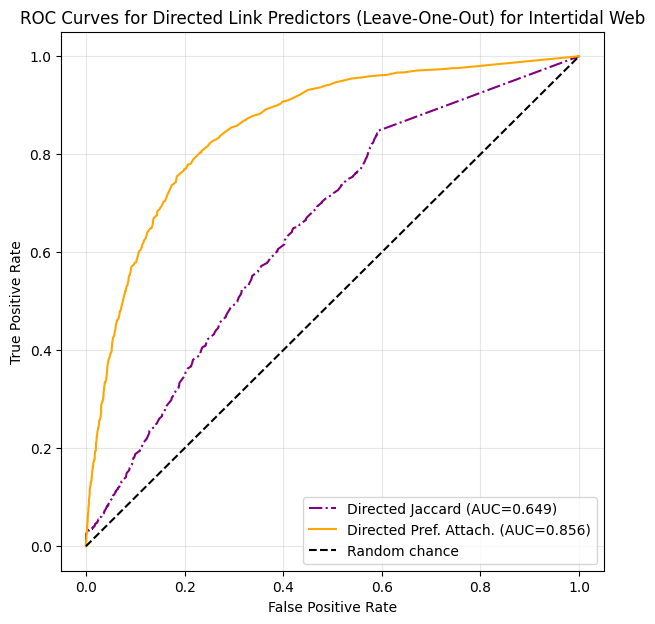

AUC (Directed Jaccard): 0.6490
AUC (Directed Preferential Attachment): 0.8557


In [18]:


probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_intertidal)
probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_intertidal)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out) for Intertidal Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa:.4f}")

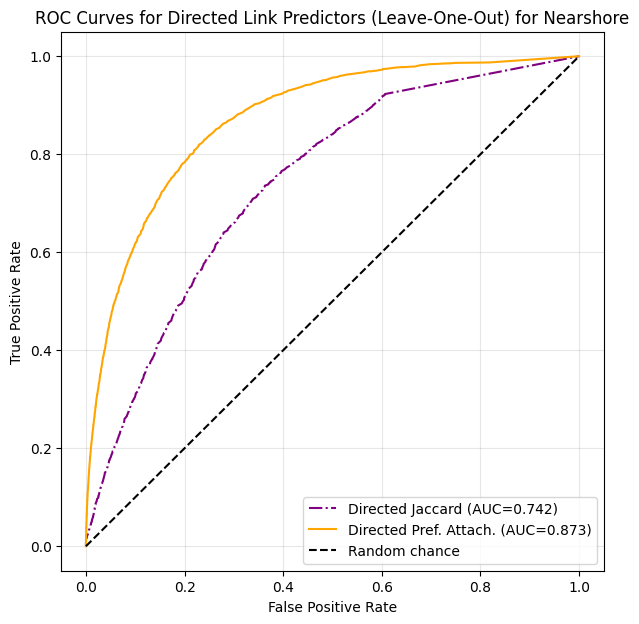

AUC (Directed Jaccard): 0.7419
AUC (Directed Preferential Attachment): 0.8731


In [19]:


probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_nearshore)
probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_nearshore)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out) for Nearshore")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa:.4f}")

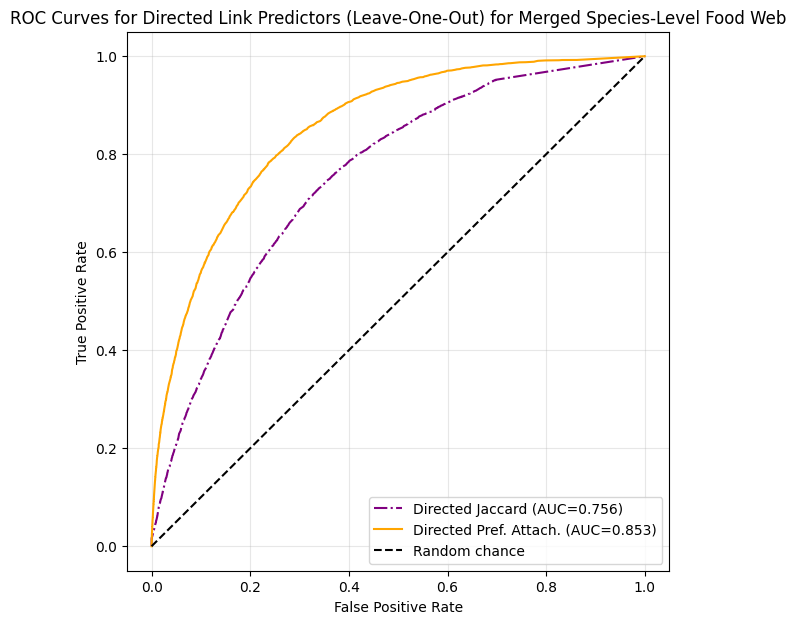

AUC (Directed Jaccard): 0.7559
AUC (Directed Preferential Attachment): 0.8534


In [20]:

probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_merged)
probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_merged)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out) for Merged Species-Level Food Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment): {auc_pa:.4f}")

In [21]:

def getPredictionsLeaveKOutDirectedJaccard(G, k=5, n_neg=5):
    """
    Iterates over the entire graph, removing k edges at a time.
    For each batch:
      - compute directed Jaccard for the k removed edges (positives)
      - sample n_neg * k random non-edges as negatives.
    Returns full lists of probs and labels for all batches.
    """
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_jaccard_coefficient(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_jaccard_coefficient(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels

def getPredictionsLeaveKOutDirectedPA(G, k=5, n_neg=5):
    probs, labels = [], []
    edges = list(G.edges())
    nodes = list(G.nodes())
    all_pairs = [(a, b) for a in nodes for b in nodes if a != b]

    random.shuffle(edges)
    batches = [edges[i:i+k] for i in range(0, len(edges), k)]

    for batch_edges in batches:
        Gprobed = G.copy()
        Gprobed.remove_edges_from(batch_edges)

        for (u, v) in batch_edges:
            p = directed_preferential_attachment(Gprobed, u, v)
            probs.append(p)
            labels.append(1)

        non_edges = [(a, b) for (a, b) in all_pairs if not Gprobed.has_edge(a, b)]
        if len(non_edges) == 0:
            continue
        n_neg_total = min(len(non_edges), n_neg * len(batch_edges))
        sampled_neg = random.sample(non_edges, n_neg_total)

        for (a, b) in sampled_neg:
            p = directed_preferential_attachment(Gprobed, a, b)
            probs.append(p)
            labels.append(0)

    return probs, labels


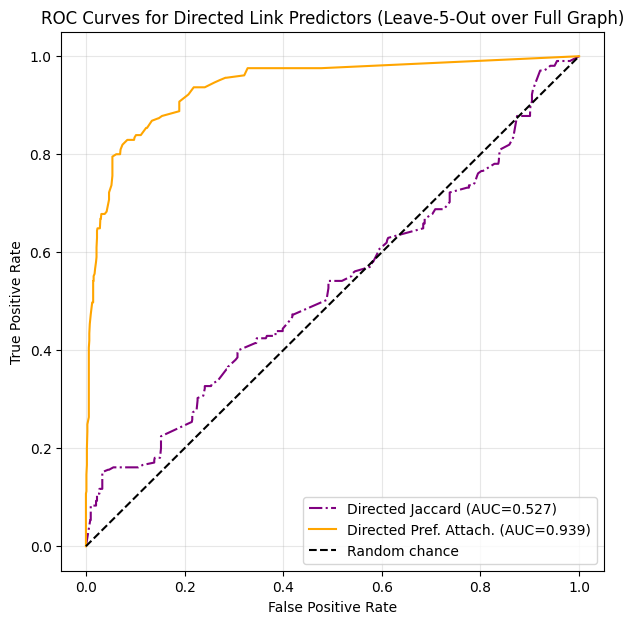

AUC (Directed Jaccard, k=5): 0.5273
AUC (Directed Pref. Attach., k=5): 0.9394


In [22]:

probs_j, labels_j = getPredictionsLeaveKOutDirectedJaccard(G_merged_phy, k=5, n_neg=5)
probs_pa, labels_pa = getPredictionsLeaveKOutDirectedPA(G_merged_phy, k=5, n_neg=5)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)
auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-5-Out over Full Graph)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard, k=5): {auc_j:.4f}")
print(f"AUC (Directed Pref. Attach., k=5): {auc_pa:.4f}")



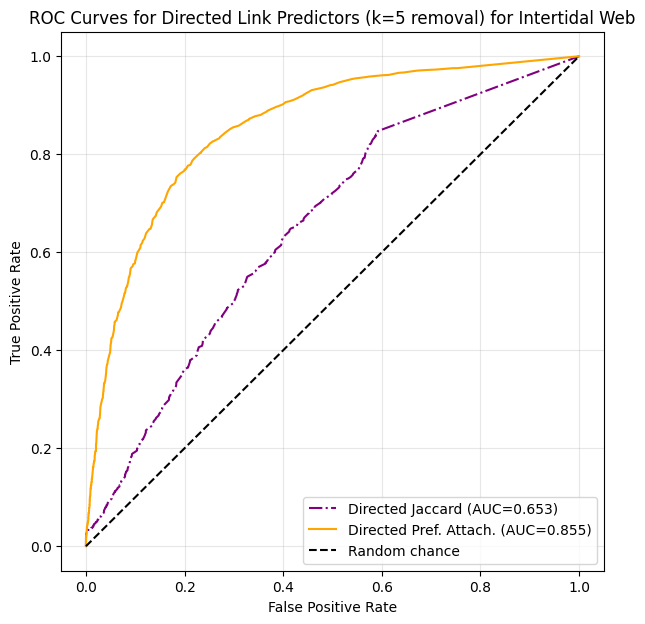

AUC (Directed Jaccard, k=5): 0.6530
AUC (Directed Preferential Attachment, k=5): 0.8554


In [23]:


probs_j, labels_j = getPredictionsLeaveKOutDirectedJaccard(G_intertidal, k=5, n_neg=5)
probs_pa, labels_pa = getPredictionsLeaveKOutDirectedPA(G_intertidal, k=5, n_neg=5)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)
auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (k=5 removal) for Intertidal Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard, k=5): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment, k=5): {auc_pa:.4f}")


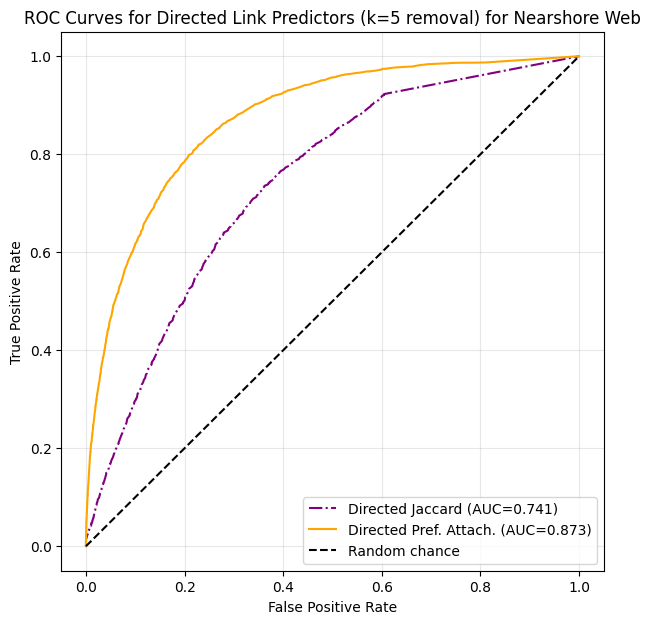

AUC (Directed Jaccard, k=5): 0.7408
AUC (Directed Preferential Attachment, k=5): 0.8735


In [24]:


probs_j, labels_j = getPredictionsLeaveKOutDirectedJaccard(G_nearshore, k=5, n_neg=5)
probs_pa, labels_pa = getPredictionsLeaveKOutDirectedPA(G_nearshore, k=5, n_neg=5)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)
auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (k=5 removal) for Nearshore Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard, k=5): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment, k=5): {auc_pa:.4f}")


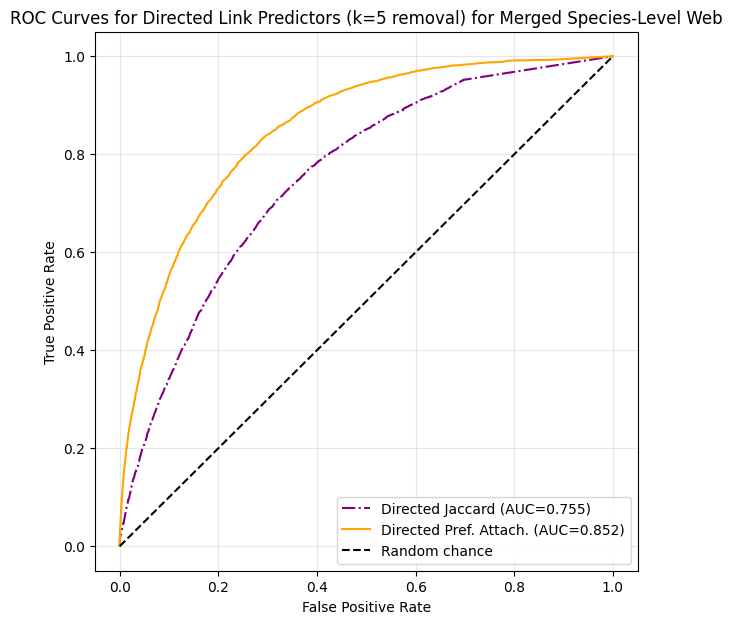

AUC (Directed Jaccard, k=5): 0.7553
AUC (Directed Preferential Attachment, k=5): 0.8519


In [25]:


probs_j, labels_j = getPredictionsLeaveKOutDirectedJaccard(G_merged, k=5, n_neg=5)
probs_pa, labels_pa = getPredictionsLeaveKOutDirectedPA(G_merged, k=5, n_neg=5)

fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)
auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (k=5 removal) for Merged Species-Level Web")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard, k=5): {auc_j:.4f}")
print(f"AUC (Directed Preferential Attachment, k=5): {auc_pa:.4f}")


In [26]:
def directed_preferential_attachment(G, u, v):
    """Directed preferential attachment = outdegree(u) * indegree(v)."""
    return G.out_degree(u) * G.in_degree(v)
def directed_jaccard_coefficient(G, u, v):
    """Directed Jaccard using both in- and out-neighbors."""
    neigh_u = set(G.successors(u)) | set(G.predecessors(u))
    neigh_v = set(G.successors(v)) | set(G.predecessors(v))
    if not neigh_u or not neigh_v:
        return 0.0
    return len(neigh_u & neigh_v) / len(neigh_u | neigh_v)
def getPredictionsLeaveOneOutDirectedJaccard(G):
    """
    Pure leave-one-out version of directed Jaccard.
    For every edge removed, compute similarity for *all* node pairs.
    """
    probs, labels = [], []

    for e in list(G.edges()):
        u, v = e
        Gprobed = G.copy()
        Gprobed.remove_edge(u, v)

        for a in Gprobed.nodes():
            for b in Gprobed.nodes():
                if a == b:
                    continue
                p = directed_jaccard_coefficient(Gprobed, a, b)
                probs.append(p)
                if (a == u and b == v):
                    labels.append(1)
                else:
                    labels.append(0)

    return probs, labels



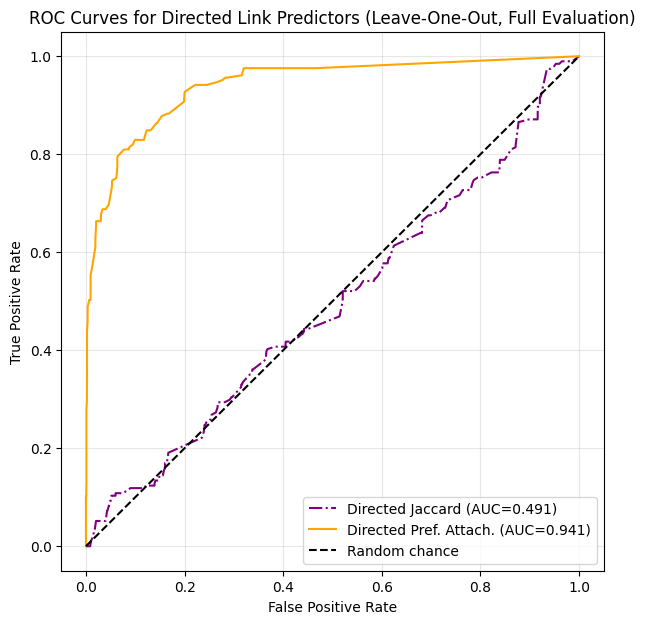

AUC (Directed Jaccard): 0.4913
AUC (Directed Pref. Attach.): 0.9407


In [27]:
probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_merged_phy)
probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_merged_phy)



fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

auc_j = roc_auc_score(labels_j, probs_j)
auc_pa = roc_auc_score(labels_pa, probs_pa)

plt.figure(figsize=(7, 7))
plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
plt.plot([0, 1], [0, 1], "--k", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out, Full Evaluation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC (Directed Jaccard): {auc_j:.4f}")
print(f"AUC (Directed Pref. Attach.): {auc_pa:.4f}")


In [28]:
# probs_j, labels_j = getPredictionsLeaveOneOutDirectedJaccard(G_intertidal)
# probs_pa, labels_pa = getPredictionsLeaveOneOutDirectedPA(G_intertidal)



# fpr_j, tpr_j, _ = roc_curve(labels_j, probs_j)
# fpr_pa, tpr_pa, _ = roc_curve(labels_pa, probs_pa)

# auc_j = roc_auc_score(labels_j, probs_j)
# auc_pa = roc_auc_score(labels_pa, probs_pa)

# plt.figure(figsize=(7, 7))
# plt.plot(fpr_j, tpr_j, "-.", label=f"Directed Jaccard (AUC={auc_j:.3f})", color="purple")
# plt.plot(fpr_pa, tpr_pa, "-", label=f"Directed Pref. Attach. (AUC={auc_pa:.3f})", color="orange")
# plt.plot([0, 1], [0, 1], "--k", label="Random chance")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves for Directed Link Predictors (Leave-One-Out, Full Evaluation)")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# print(f"AUC (Directed Jaccard): {auc_j:.4f}")
# print(f"AUC (Directed Pref. Attach.): {auc_pa:.4f}")